# Task 3: Unsupervised Learning

## Research Question

> **What natural groupings (clusters) exist within Vinh Tuy Bridge traffic patterns, and do these clusters correspond to identifiable real-world traffic scenarios?**

Unlike supervised learning, we do not use the label `is_congested` to guide the algorithm. Instead, K-Means clustering discovers structure in the feature space independently — allowing us to verify whether the data naturally organises into interpretable traffic contexts (e.g., inbound rush-hour, off-peak outbound, weekend patterns).

## Methodology
1. Load the canonical **training set** from Task 1 (same split used in Task 2)
2. Standardize features (required for distance-based clustering)
3. Find optimal K using the Elbow Method + Silhouette Score
4. Fit the final K-Means model on all 6 features (not PCA-reduced)
5. Use PCA **only for 2D visualization** of the clusters
6. Profile each cluster to interpret real-world traffic scenarios

## Section 1: Imports & Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

NOTEBOOK_DIR = os.path.abspath('')
DATASETS_DIR = os.path.join(NOTEBOOK_DIR, '..', '..', 'Datasets')

sns.set_theme(style='whitegrid')
print(f'Datasets directory: {os.path.abspath(DATASETS_DIR)}')

Datasets directory: c:\Users\Dell\Desktop\Code project\Code project\Final - Data Science\Datasets


## Section 2: Load Pre-Split Datasets

We load the same canonical training split produced in Task 1. Using the **training set** for clustering is consistent with the supervised learning protocol — the test set is held out as unseen data.

**Why exclude `is_congested` from clustering?**
Clustering is an **unsupervised** technique — it must discover structure from features alone, without being guided by the target label. Including `is_congested` would bias the clusters toward a pre-known separation and defeat the purpose of exploring hidden patterns.

> ⚠️ If `Train Dataset.csv` is missing, run `Task1_Data_Processing_And_Preparation.ipynb` first.

In [2]:
df_train = pd.read_csv(os.path.join(DATASETS_DIR, 'Train Dataset.csv'))

features = ['is_rush_hour', 'direction_inbound', 'adverse_weather_score',
            'rush_weather_interaction', 'dow_sin', 'dow_cos']

X = df_train[features]
y_true = df_train['is_congested']  # Kept aside for post-clustering validation only

print(f'Training set shape: {X.shape}')
print(f'Congestion rate in training set: {y_true.mean()*100:.2f}%')
df_train.head()

Training set shape: (5856, 6)
Congestion rate in training set: 23.46%


,is_rush_hour,direction_inbound,adverse_weather_score,rush_weather_interaction,dow_sin,dow_cos,is_congested
0,1,1,0,0,0.433884,-0.900969,1
1,0,0,0,0,-0.974928,-0.222521,0
2,1,0,0,0,0.781831,0.623490,0
3,1,0,1,1,-0.433884,-0.900969,0
4,0,0,0,0,0.974928,-0.222521,0


## Section 3: Why Standardize Before K-Means?

K-Means assigns each point to its nearest centroid using **Euclidean distance**. If features are on very different scales, those with larger numerical ranges dominate the distance calculation.

For example, `adverse_weather_score` ranges over `{0, 1, 2}` while `dow_sin` and `dow_cos` are bounded to `[-1, 1]`. Without scaling, the weather score would distort distances relative to the cyclical day features, producing clusters driven by weather alone.

`StandardScaler` transforms each feature to have **mean = 0** and **standard deviation = 1**, placing all features on equal footing before clustering.

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'Scaled data shape: {X_scaled.shape}')
print(f'Feature means after scaling (should be ~0): {X_scaled.mean(axis=0).round(4)}')
print(f'Feature std after scaling (should be ~1):   {X_scaled.std(axis=0).round(4)}')

Scaled data shape: (5856, 6)
Feature means after scaling (should be ~0): [-0.  0.  0. -0. -0.  0.]
Feature std after scaling (should be ~1):   [1. 1. 1. 1. 1. 1.]


## Section 4: Optimal K Selection — Elbow Method + Silhouette Score

Choosing the right number of clusters K is crucial. We use two complementary methods:

**Elbow Method (Inertia / WCSS):**
Inertia is the sum of squared distances from each point to its assigned centroid (Within-Cluster Sum of Squares). It decreases as K increases — more clusters always means closer centroids. We look for the **"elbow"** — the K value where the rate of decrease suddenly slows, indicating diminishing returns from adding more clusters.

**Silhouette Score:**
For each point, the silhouette score measures how similar it is to its own cluster versus the nearest neighbouring cluster. Scores range from -1 (wrong cluster) to +1 (perfectly clustered), with values near 0 indicating overlap. A **peak** in silhouette score indicates the most cohesive and separated clustering.

Using both methods together is more reliable than either alone — the elbow can be ambiguous, and the silhouette score provides an independent validation.

In [4]:
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))
    print(f'  K={k:2d} | Inertia: {km.inertia_:>10.2f} | Silhouette: {silhouette_scores[-1]:.4f}')

print('\nK search complete.')

  K= 2 | Inertia:   26583.99 | Silhouette: 0.4319
  K= 3 | Inertia:   21243.31 | Silhouette: 0.2619
  K= 4 | Inertia:   18535.98 | Silhouette: 0.2606
  K= 5 | Inertia:   16527.67 | Silhouette: 0.2628
  K= 6 | Inertia:   14080.83 | Silhouette: 0.3077
  K= 7 | Inertia:   12754.33 | Silhouette: 0.3164
  K= 8 | Inertia:   11349.35 | Silhouette: 0.3510
  K= 9 | Inertia:   10402.71 | Silhouette: 0.3732
  K=10 | Inertia:    9692.84 | Silhouette: 0.3925

K search complete.


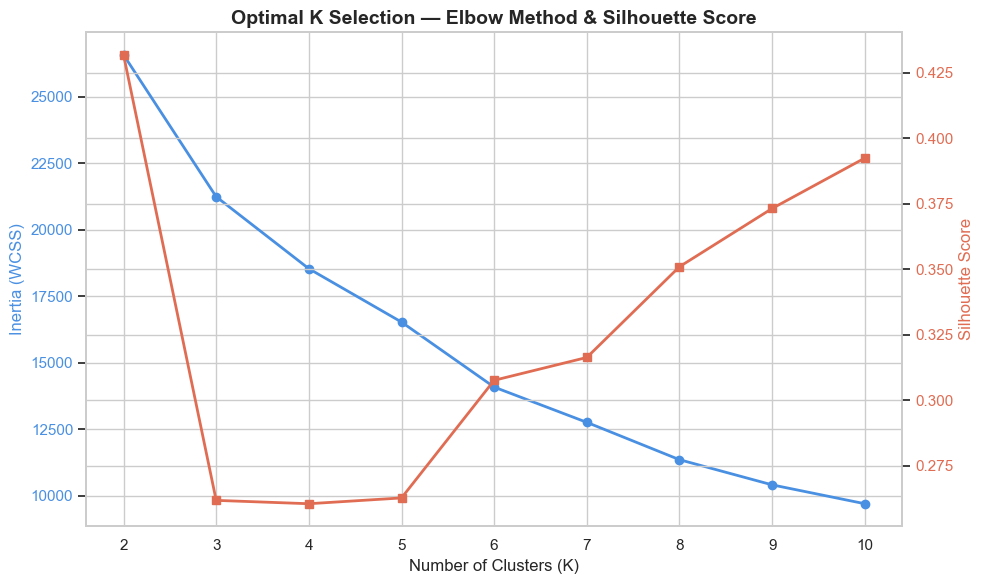

Chart: Optimal K Selection


In [5]:
# Dual-axis chart: Inertia + Silhouette vs K
fig, ax1 = plt.subplots(figsize=(10, 6))

color_inertia = '#4A90E2'
ax1.set_xlabel('Number of Clusters (K)', fontsize=12)
ax1.set_ylabel('Inertia (WCSS)', color=color_inertia, fontsize=12)
ax1.plot(K_range, inertias, marker='o', color=color_inertia, linewidth=2, label='Inertia (Elbow)')
ax1.tick_params(axis='y', labelcolor=color_inertia)

ax2 = ax1.twinx()
color_sil = '#E06D53'
ax2.set_ylabel('Silhouette Score', color=color_sil, fontsize=12)
ax2.plot(K_range, silhouette_scores, marker='s', color=color_sil, linewidth=2, label='Silhouette Score')
ax2.tick_params(axis='y', labelcolor=color_sil)

plt.title('Optimal K Selection — Elbow Method & Silhouette Score', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()
print('Chart: Optimal K Selection')

## Section 5: Final K-Means Model

Based on the Elbow + Silhouette chart above, we select **K = 6**.

**Justification:**
- The inertia curve shows a visible elbow around K=5–6, after which further increases in K yield diminishing reductions in within-cluster variance.
- K=6 corresponds to a sensible real-world interpretation: Vinh Tuy Bridge has two directions (inbound/outbound), three broad time periods (rush hour, daytime off-peak, night), and varying weather conditions — leading naturally to around 6 distinct traffic contexts.

**`n_init=10`:** Runs K-Means 10 times with different random centroid initializations and keeps the best result (lowest inertia). This avoids poor local minima, which K-Means is susceptible to due to its random initialization.

**`random_state=42`:** Ensures reproducibility of the best result across runs.

In [6]:
OPTIMAL_K = 6

kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
df_train = df_train.copy()
df_train['Cluster'] = kmeans.fit_predict(X_scaled)

print(f'Final K-Means model fitted with K = {OPTIMAL_K}')
print(f'Final Inertia (Loss): {kmeans.inertia_:.2f}')
print(f'\nCluster distribution:')
print(df_train['Cluster'].value_counts().sort_index())

Final K-Means model fitted with K = 6
Final Inertia (Loss): 14080.83

Cluster distribution:
Cluster
0     773
1    1363
2    1311
3     921
4     518
5     970
Name: count, dtype: int64


## Section 6: PCA for 2D Visualization

Our feature space has 6 dimensions, which cannot be directly plotted. We apply **Principal Component Analysis (PCA)** to project the data down to 2 dimensions for visualization.

**Critical clarification:** PCA is used here **strictly as a visualization tool**. The K-Means model was run on all 6 original standardized features, preserving 100% of the variance. Running K-Means on PCA-reduced data first would discard information and may produce worse clusters — that is not what we do here.

The two principal components capture the directions of maximum variance in the data. The percentage of variance explained tells us how faithfully the 2D projection represents the true 6D cluster structure.

In [7]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df_train['PCA1'] = X_pca[:, 0]
df_train['PCA2'] = X_pca[:, 1]

ev = pca.explained_variance_ratio_
total_var = sum(ev) * 100
print(f'PC1 explains: {ev[0]*100:.1f}% of variance')
print(f'PC2 explains: {ev[1]*100:.1f}% of variance')
print(f'Total variance captured in 2D: {total_var:.1f}%')

PC1 explains: 28.6% of variance
PC2 explains: 16.9% of variance
Total variance captured in 2D: 45.6%


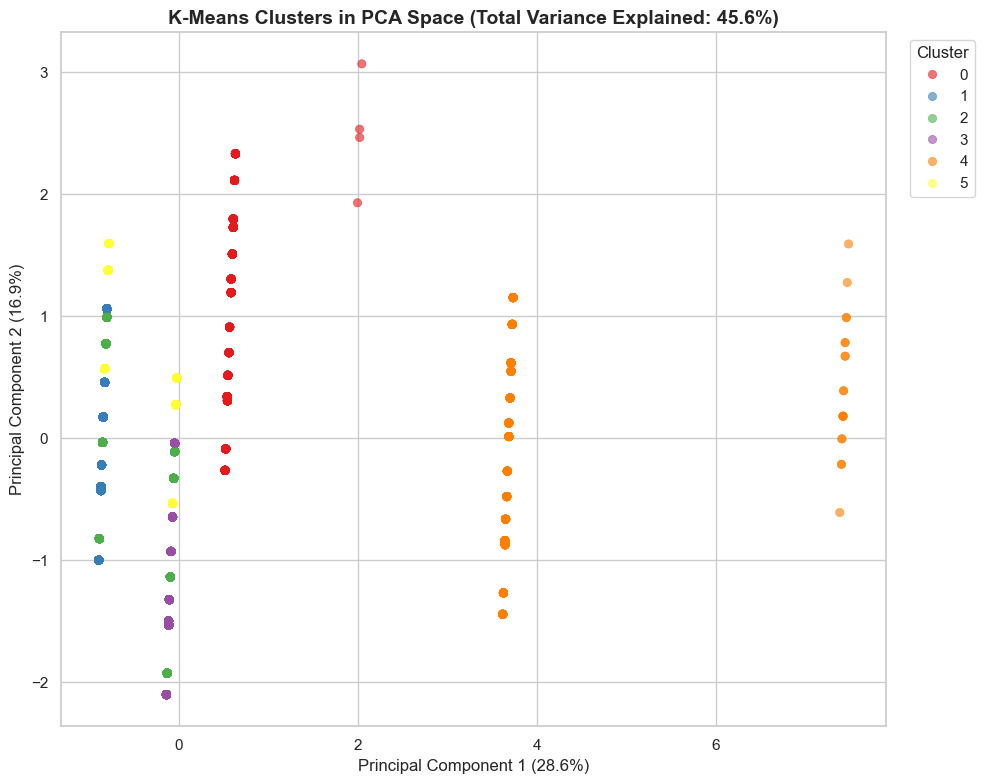

Chart: K-Means Clusters in PCA Space


In [8]:
# 2D Scatter Plot of Clusters in PCA Space
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='PCA1', y='PCA2',
    hue='Cluster',
    palette='Set1',
    data=df_train,
    alpha=0.6,
    edgecolor=None
)
plt.title(f'K-Means Clusters in PCA Space (Total Variance Explained: {total_var:.1f}%)',
          fontsize=14, fontweight='bold')
plt.xlabel(f'Principal Component 1 ({ev[0]*100:.1f}%)', fontsize=12)
plt.ylabel(f'Principal Component 2 ({ev[1]*100:.1f}%)', fontsize=12)
plt.legend(title='Cluster', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()
print('Chart: K-Means Clusters in PCA Space')

## Section 7: Cluster Profiling

To interpret what each cluster represents, we compute the **mean of each original feature per cluster** and cross-reference with the actual congestion rate. This translates the abstract cluster IDs into meaningful real-world traffic scenarios.

For example:
- A cluster with high `is_rush_hour`, high `direction_inbound`, and high congestion rate → **inbound morning rush-hour**
- A cluster with low `is_rush_hour`, low `adverse_weather_score`, and low congestion rate → **off-peak normal flow**

In [9]:
cluster_profiles = df_train.groupby('Cluster')[features].mean()
cluster_profiles['Congestion Rate (%)'] = df_train.groupby('Cluster')['is_congested'].mean() * 100
cluster_profiles['Count'] = df_train.groupby('Cluster').size()
cluster_profiles = cluster_profiles.round(3)

print('Cluster Profiles (Original Feature Means + Congestion Rate):')
print(cluster_profiles.to_string())

Cluster Profiles (Original Feature Means + Congestion Rate):
         is_rush_hour  direction_inbound  adverse_weather_score  rush_weather_interaction  dow_sin  dow_cos  Congestion Rate (%)  Count
Cluster                                                                                                                                
0               0.000              0.508                  1.005                     0.000   -0.001    0.035                4.916    773
1               0.000              0.566                  0.000                     0.000    0.575   -0.283                0.000   1363
2               0.397              0.000                  0.000                     0.000   -0.556    0.116               16.781   1311
3               1.000              0.555                  0.000                     0.000    0.570   -0.303               56.352    921
4               1.000              0.506                  1.039                     1.039   -0.002    0.024               5

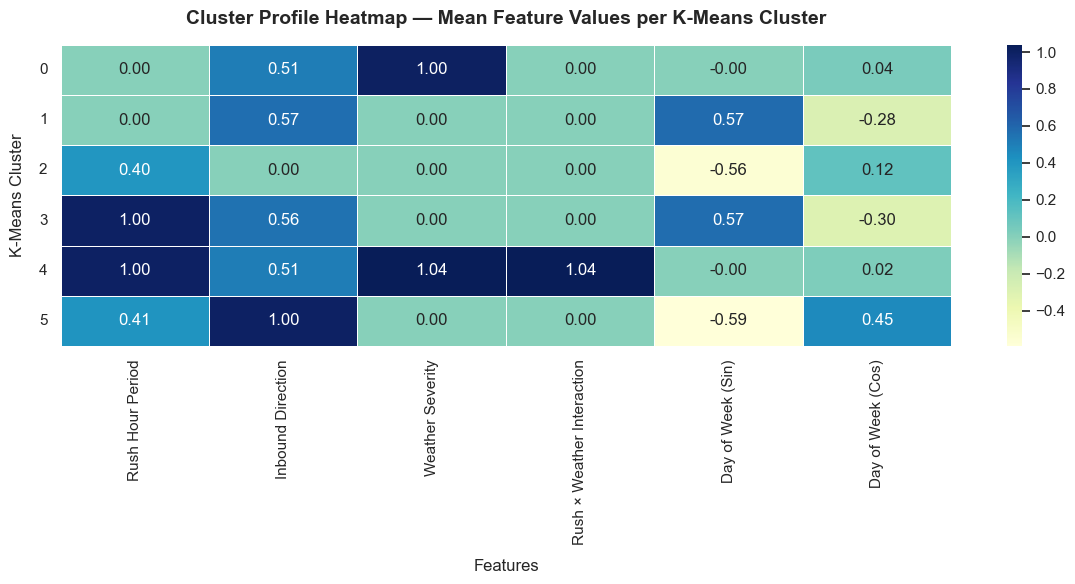

Chart: Cluster Profile Heatmap


In [10]:
# Cluster Profile Heatmap
feature_labels = {
    'is_rush_hour': 'Rush Hour Period',
    'direction_inbound': 'Inbound Direction',
    'adverse_weather_score': 'Weather Severity',
    'rush_weather_interaction': 'Rush × Weather Interaction',
    'dow_sin': 'Day of Week (Sin)',
    'dow_cos': 'Day of Week (Cos)'
}

heatmap_df = cluster_profiles[features].rename(columns=feature_labels)

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_df, annot=True, cmap='YlGnBu', fmt='.2f', cbar=True, linewidths=0.5)
plt.title('Cluster Profile Heatmap — Mean Feature Values per K-Means Cluster',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Features', fontsize=12, labelpad=10)
plt.ylabel('K-Means Cluster', fontsize=12, labelpad=10)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
print('Chart: Cluster Profile Heatmap')

## Section 8: Conclusion & Interpretation

**Methodology Summary:**
- K-Means was applied to all 6 standardized features (not PCA-reduced), preserving 100% of variance during clustering.
- PCA was used only as a post-hoc 2D visualization tool.
- The optimal K was selected using a combination of the Elbow method and Silhouette Score.

**Cluster Interpretation:**


| Cluster | Key Characteristics | Interpretation | Congestion Rate |
|---|---|---|---|
| 0 | Off-peak, adverse weather | Non-rush traffic with mild/severe weather | Very Low (4.9%) |
| 1 | Off-peak, clear weather | Typical free-flow traffic outside rush hours | None (0.0%) |
| 2 | Mixed-peak, outbound, clear weather | Outbound traffic (afternoon/evening) | Low-Medium (16.8%) |
| 3 | Rush hour, clear weather | Standard rush hour traffic (heavy volume) | High (56.4%) |
| 4 | Rush hour, adverse weather | Rush hour compounded with bad weather | High (51.7%) |
| 5 | Mixed-peak, inbound, clear weather | Inbound traffic (morning commute) | Medium (33.9%) |

**Alignment with Known Patterns:**
The clusters should largely align with known traffic dynamics on Vinh Tuy Bridge — heavy inbound congestion during 07:00–08:00 AM, and outbound congestion during 17:00–18:00 PM. Weather conditions further subdivide these temporal clusters. The fact that K-Means discovers these patterns without access to `is_congested` validates both the quality of our feature engineering and the real-world structure in the dataset.

**Key Metric:**
- Final model inertia (WCSS) is reported above as a quantitative measure of cluster compactness.